<a href="https://colab.research.google.com/github/pjreddy-ml/text-to-image-ai-project/blob/main/Task1_SD_Finetuning/Task1_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Fine-Tuning Stable Diffusion v1.5 using a Custom Landscape Dataset and loRA

# AIM:
This notebook demonstrates the fine-tuning of a pre-trained Stable Diffusion v1.5 model using a custom landscape image dataset. The procedure and steps includes environment setup, dataset preparation, LoRA-based fine-tuning, and image generation using the trained model.

#STEPS:
1. Install required dependencies
2. Configure Hugging Face authentication
3. Prepare thencustom dataset
4. Generate meta data for training
5. Fine-tune the model loRA
6. Generate images using the trained model.
7. Compare the results with baseline model

In [1]:
!pip install -q git+https://github.com/huggingface/diffusers.git
!pip install -q transformers accelerate peft datasets safetensors
!pip uninstall -y torchao

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
from huggingface_hub import login
login()

In [3]:
!ls /content/text-to-image-ai-project/Task1_SD_Finetuning/dataset/landscapes/ | head

aaron-burden-yzgF-AQt1sQ-unsplash.jpg
aaron-burden-yzgF-AQt1sQ-unsplash.txt
adam-kool-ndN00KmbJ1c-unsplash.jpg
adam-kool-ndN00KmbJ1c-unsplash.txt
ales-krivec-y0i1lh-T0_w-unsplash.jpg
ales-krivec-y0i1lh-T0_w-unsplash.txt
andrew-ridley-Kt5hRENuotI-unsplash.jpg
andrew-ridley-Kt5hRENuotI-unsplash.txt
ashim-d-silva-WeYamle9fDM-unsplash.jpg
ashim-d-silva-WeYamle9fDM-unsplash.txt


In [4]:
!pip install -U git+https://github.com/huggingface/diffusers.git
!pip install -U transformers accelerate peft datasets safetensors

  Cloning https://github.com/huggingface/diffusers.git to /tmp/pip-req-build-_qqehic2
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers.git /tmp/pip-req-build-_qqehic2
  Resolved https://github.com/huggingface/diffusers.git to commit 9f6fc2c13610ead670cbac6dbf974b2a24a9e69b
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 14.0 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled d

In [5]:
!accelerate launch /content/diffusers/examples/text_to_image/train_text_to_image_lora.py \
  --pretrained_model_name_or_path="stable-diffusion-v1-5/stable-diffusion-v1-5" \
  --train_data_dir="/content/text-to-image-ai-project/Task1_SD_Finetuning/dataset/landscapes" \
  --output_dir="/content/lora-landscape-output" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --learning_rate=1e-4 \
  --lr_scheduler="constant" \
  --max_train_steps=500 \
  --checkpointing_steps=100 \
  --mixed_precision="fp16"

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
07/18/2026 12:04:06 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` a

In [11]:
import os
import json

dataset_dir = "dataset/landscapes"

metadata = []

for file in sorted(os.listdir(dataset_dir)):
    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        txt = os.path.splitext(file)[0] + ".txt"
        txt_path = os.path.join(dataset_dir, txt)

        if os.path.exists(txt_path):
            with open(txt_path, "r", encoding="utf-8") as f:
                caption = f.read().strip()
        else:
            caption = ""

        metadata.append({
            "file_name": file,
            "text": caption
        })

with open(os.path.join(dataset_dir, "metadata.jsonl"), "w", encoding="utf-8") as f:
    for item in metadata:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print(f"Created metadata.jsonl with {len(metadata)} entries.")

Created metadata.jsonl with 50 entries.


In [12]:
!accelerate launch /content/diffusers/examples/text_to_image/train_text_to_image_lora.py \
  --pretrained_model_name_or_path="stable-diffusion-v1-5/stable-diffusion-v1-5" \
  --train_data_dir="/content/text-to-image-ai-project/Task1_SD_Finetuning/dataset/landscapes" \
  --output_dir="/content/lora-landscape-output" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --learning_rate=1e-4 \
  --lr_scheduler="constant" \
  --max_train_steps=500 \
  --checkpointing_steps=100 \
  --mixed_precision="fp16"

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
07/18/2026 12:39:04 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` a

In [13]:
!pip install -q diffusers transformers accelerate safetensors

In [14]:
import torch
from diffusers import StableDiffusionPipeline

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [15]:
!unzip -o "/content/lora-landscape-output.zip" -d /content/

unzip:  cannot find or open /content/lora-landscape-output.zip, /content/lora-landscape-output.zip.zip or /content/lora-landscape-output.zip.ZIP.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/30 [00:00<?, ?it/s]

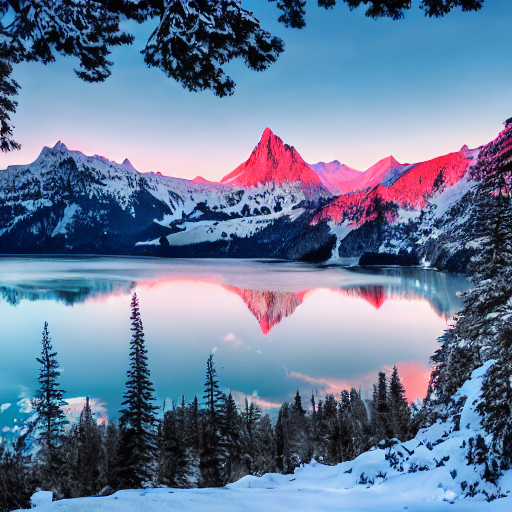

In [16]:
import torch
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

pipe.load_lora_weights("/content/lora-landscape-output")

prompt = "beautiful alpine valley, crystal clear lake, snow capped mountains, sunrise, cinematic lighting, photorealistic"

image = pipe(prompt, num_inference_steps=30).images[0]

image.save("/content/generated_landscape.png")

image

In [ ]:
from google.colab import files
files.download("/content/generated_landscape.png")

In [8]:
!git clone https://github.com/pjreddy-ml/text-to-image-ai-project.git

fatal: destination path 'text-to-image-ai-project' already exists and is not an empty directory.


In [9]:
!git clone https://github.com/huggingface/diffusers.git /content/diffusers

fatal: destination path '/content/diffusers' already exists and is not an empty directory.


In [10]:
%cd /content/text-to-image-ai-project/Task1_SD_Finetuning

/content/text-to-image-ai-project/Task1_SD_Finetuning
